# Calcolo del covering factor con regime ADAF per i 13 blazar considerati e delle sue relazioni con le proprietà dei blazar (redshift, luminosità della BLR)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.optimize import root
from scipy.special import kv

file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

In [17]:
# ==========================================================
# SCENARI ADAF
# ==========================================================
SCENARI_ADAF = [
    {
        "scenario": r"LBL: $\dot m$ =5.7e-3",
        "m": 1e9,
        "mdot": 5.7e-3,
        "beta": 0.5
    },
    {
        "scenario": r"IBL: $\dot m$ =5e-4",
        "m": 1e9,
        "mdot": 5.0e-4,
        "beta": 0.5
    },
    {
        "scenario": r"LBL: $\dot m$ =3e-4",
        "m": 1e9,
        "mdot": 3.0e-4,
        "beta": 0.5
    }
]

In [18]:
# ==========================================================
# COSTANTI
# ==========================================================
ALFA = 0.3
RMIN = 3.0
RMAX = 1000.0
DELTA = 0.0
C1 = 0.5
C3 = 0.3
TNORM = 1.68e-10

# ==========================================================
# FUNZIONI MATEMATICHE
# ==========================================================
def bessk(n, x):
    return kv(n, x)

def g(teta):
    return (1.0 / bessk(2, 1.0 / teta)) * (2.0 + 2.0 * teta + 1.0 / teta) * np.exp(-1.0 / teta)

# ==========================================================
# SISTEMA NON LINEARE
# ==========================================================
def temperat(y, mdot, m, beta):

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm

    # Heating
    q1 = 1.2e4 * g(teta) * ALFA**(-2) * C1**(-2) * C3 * beta * m * mdot**2 / RMIN
    q2 = DELTA * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN
    q = q1 + q2

    # Synchrotron
    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / TNORM)**2 * RMIN**(-5/4)
    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * TNORM))**7 *
        m**0.5 * mdot**1.5
    )

    # Compton inverso
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)
    graffa = ((6.2e7 * (teta / (1e9 * TNORM))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    # Bremsstrahlung
    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * ALFA**(-2) * C1**(-2) * np.log(RMAX/RMIN) * f * m * mdot**2

    # Equazioni
    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * C3 * m * mdot / RMIN - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]

# ==========================================================
# SPETTRO
# ==========================================================
def spectrum(te, f, xm, m, mdot, beta, savefile=None):

    numin = 1e10
    numax = 1e21
    num = 100

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = 1.68e-10 * te

    s1 = 1.42e9 * ALFA**(-0.5) * np.sqrt(1 - beta) * C1**(-0.5) * C3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24
    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * RMIN**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(RMIN)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    for i in range(num):
        # SYNCHROTRON
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )
        else:
            lls[i] = -np.inf

        # COMPTON
        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff
        else:
            llc[i] = -np.inf

        # BREMS
        if teta < 1:
            fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
        else:
            fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

        base_b = (
            24.36
            - 2*np.log10(ALFA*C1)
            + np.log10(np.log(RMAX/RMIN) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )
        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    comp_sync = np.where(np.isfinite(lls), 10**lls, 0.0)
    comp_comp = np.where(np.isfinite(llc), 10**llc, 0.0)
    comp_brems = np.where(np.isfinite(llb), 10**llb, 0.0)

    flux = comp_sync + comp_comp + comp_brems
    y = lnu + np.log10(flux)

    if savefile is not None:
        np.savetxt(savefile, np.column_stack([lnu, y]))
        print(f"File salvato: {savefile}")

    return lnu, y, lls, llc, llb


# ==========================================================
# SPECDATA
# ==========================================================
def specdata(m, mdot, beta, savefile=None, verbose=True):

    if verbose:
        print(f"m = {m}")
        print(f"mdot = {mdot}")
        print(f"beta = {beta}")

    y0 = [0.5, 1.0, 0.99]
    sol = root(temperat, y0, args=(mdot, m, beta), tol=1e-10)

    if not sol.success:
        raise RuntimeError(f"La soluzione non converge per m={m}, mdot={mdot}, beta={beta}")

    y = sol.x
    teta = y[0]**2
    te = teta / 1.68e-10
    xm = 1e3 * y[1]**2
    f = y[2]**2

    if verbose:
        print("\n=== OUTPUT ===")
        print("te   =", te)
        print("xm   =", xm)
        print("f    =", f)

    lnu, spettro_tot, lls, llc, llb = spectrum(
        te, f, xm, m, mdot, beta, savefile=savefile
    )

    return {
        "lnu": lnu,
        "log_nuFnu": spettro_tot,
        "log_sync": lls,
        "log_compton": llc,
        "log_brems": llb,
        "te": te,
        "xm": xm,
        "f": f,
        "m": m,
        "mdot": mdot,
        "beta": beta
    }

In [19]:
# ==========================================================
# FUNZIONI DI SUPPORTO
# ==========================================================

def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
    nome_transizione   E_ion   nu_ion
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=('U50', float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns):
    """
    Estrae le linee osservate positive da una riga del dataframe.
    """
    risultati = []

    for col in norm_columns:
        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line
        })

    return pd.DataFrame(risultati)

In [20]:
# ==========================================================
# COSTRUZIONE SPETTRO ADAF
# ==========================================================

def costruisci_spettro_adaf(m, mdot, beta, verbose=False):
    """
    Usa specdata() per ottenere lo spettro ADAF e restituisce:
        nu      [Hz]
        Lnu     [erg s^-1 Hz^-1]
        nuLnu   [erg s^-1]
        info    dict con parametri fisici
    """
    risultato = specdata(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=verbose
    )

    lnu = risultato["lnu"]                 # log10(nu)
    log_nuLnu = risultato["log_nuFnu"]     # log10(nu * Lnu)

    nu = 10**lnu
    nuLnu = 10**log_nuLnu
    Lnu = nuLnu / nu

    info = {
        "m": m,
        "mdot": mdot,
        "beta": beta,
        "te": risultato["te"],
        "xm": risultato["xm"],
        "f": risultato["f"]
    }

    return nu, Lnu, nuLnu, info

In [21]:
# ==========================================================
# CALCOLO L_ION
# ==========================================================

def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=None):
    """
    Calcola:
        L_ion = integral_{nu_ion}^{nu_max} Lnu dnu
    per ogni transizione.
    """
    risultati = []

    if nu_max is None:
        nu_max = np.max(nu)

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)

## Calcolo del covering factor

In [22]:
# ==========================================================
# ANALISI DI UN SINGOLO BLAZAR
# ==========================================================

def analizza_blazar_adaf(row, df_trans, norm_columns, mostra_grafico=True, verbose=True):
    nome_blazar = row["label"]
    m = row["m"]
    mdot = row["mdot"]
    beta = row["beta"]
    scenario_name = row["scenario"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    if verbose:
        print("=" * 80)
        print(f"Scenario = {scenario_name}")
        print(f"Blazar: {nome_blazar}")
        print(f"redshift = {redshift}")
        print(f"m = {m:.3e} Msun")
        print(f"mdot = {mdot:.3e}")
        print(f"beta = {beta:.3f}")

    # spettro ADAF
    nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
        m=m,
        mdot=mdot,
        beta=beta,
        verbose=False
    )

    if verbose:
        print("\nParametri fisici ADAF:")
        print(f"te   = {info['te']:.3e}")
        print(f"xm   = {info['xm']:.3e}")
        print(f"f    = {info['f']:.3e}")

    # L_ion teoriche
    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=np.max(nu))

    # linee osservate
    df_linee = estrai_linee_osservate(row, norm_columns)

    if verbose:
        print("\nLinee osservate del blazar:")
        display(df_linee)

    # merge e covering factor
    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[
        (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
        "covering_factor"
    ] = np.nan

    if verbose:
        print("\nConfronto finale per ogni linea:")
        display(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    return df_conf

In [23]:
# ==========================================================
# LETTURA DATI OSSERVATIVI
# ==========================================================
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)

col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()

print("Numero blazar trovati:", len(df_all))
print("Colonne di linea trovate:")
print(norm_columns)

Numero blazar trovati: 13
Colonne di linea trovate:
['MgII_norm', 'CIV_norm', 'Ha_norm', 'Hb_norm', 'CIII_norm', 'Hg_norm', 'Hd_norm']


In [24]:
# ==========================================================
# ANALISI DI TUTTI I BLAZAR IN TUTTI GLI SCENARI ADAF
# ==========================================================

tutti_risultati_scenari_adaf = []

for scenario in SCENARI_ADAF:
    df_all_scenario = df_all.copy()
    df_all_scenario["m"] = scenario["m"]
    df_all_scenario["mdot"] = scenario["mdot"]
    df_all_scenario["beta"] = scenario["beta"]
    df_all_scenario["scenario"] = scenario["scenario"]

    risultati_scenario = []

    for i in range(len(df_all_scenario)):
        row = df_all_scenario.iloc[i]

        df_conf = analizza_blazar_adaf(
            row,
            df_trans,
            norm_columns,
            mostra_grafico=False,
            verbose=False
        )

        df_conf["label"] = row["label"]
        df_conf["scenario"] = scenario["scenario"]
        df_conf["m"] = scenario["m"]
        df_conf["mdot"] = scenario["mdot"]
        df_conf["beta"] = scenario["beta"]

        risultati_scenario.append(df_conf)

    df_risultati_scenario = pd.concat(risultati_scenario, ignore_index=True)
    tutti_risultati_scenari_adaf.append(df_risultati_scenario)

df_risultati_finali_adaf = pd.concat(tutti_risultati_scenari_adaf, ignore_index=True)

print("=" * 100)
print("DataFrame finale ADAF creato")
print(f"Numero righe: {len(df_risultati_finali_adaf)}")
display(df_risultati_finali_adaf.head())


DataFrame finale ADAF creato
Numero righe: 117


,line_name,norm_value,L_line,E_ion,nu_ion,L_ion,covering_factor,label,scenario,m,mdot,beta
0,Ha,3.631777,3.631777e+42,1.89,4.600000e+14,1.420882e+43,0.255600,J1745.6,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
1,Hb,1.103068,1.103068e+42,2.55,6.200000e+14,1.399612e+43,0.078812,J1745.6,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
2,Hb,6.569277,6.569277e+42,2.55,6.200000e+14,1.399612e+43,0.469364,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
3,Hg,1.867612,1.867612e+42,2.86,6.910000e+14,1.399612e+43,0.133438,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5
4,Hd,1.343418,1.343418e+42,3.02,7.370000e+14,1.399612e+43,0.095985,J0021.6-6835,LBL: $\dot m$ =5.7e-3,1.000000e+09,0.0057,0.5


In [25]:
# ==========================================================
# TABELLE PER BLAZAR
# ==========================================================
tabelle_per_blazar_adaf = {}
blazar_unici = sorted(df_risultati_finali_adaf["label"].unique())
ordine_scenari_adaf = [s["scenario"] for s in SCENARI_ADAF]

for blazar in blazar_unici:
    df_blazar = df_risultati_finali_adaf[
        df_risultati_finali_adaf["label"] == blazar
    ].copy()

    tabella_blazar = df_blazar.pivot(
        index="scenario",
        columns="line_name",
        values="covering_factor"
    )

    tabella_blazar = tabella_blazar.reindex(
        sorted(tabella_blazar.columns),
        axis=1
    )

    tabella_blazar = tabella_blazar.reset_index()
    tabella_blazar = (
        tabella_blazar
        .set_index("scenario")
        .loc[ordine_scenari_adaf]
        .reset_index()
    )

    tabella_blazar = tabella_blazar.fillna("-")
    tabelle_per_blazar_adaf[blazar] = tabella_blazar

print(f"Tabelle create per blazar: {len(tabelle_per_blazar_adaf)}")

for blazar, tabella in tabelle_per_blazar_adaf.items():
    print("\n" + "=" * 100)
    print(f"Blazar: {blazar}")
    display(tabella)


# Salvataggio tabelle per blazar
with open("Cf_ADAF_tabelle_blazar.csv", "w") as f:
    for blazar, tabella in tabelle_per_blazar_adaf.items():
        f.write("=" * 80 + "\n")
        f.write(f"Blazar: {blazar}\n")
        f.write("=" * 80 + "\n")
        tabella.to_csv(f, index=False)
        f.write("\n\n")

Tabelle create per blazar: 13

Blazar: J0021.6-6835


line_name,scenario,Hb,Hd,Hg
0,LBL: $\dot m$ =5.7e-3,0.469364,0.095985,0.133438
1,IBL: $\dot m$ =5e-4,686.926353,140.476531,195.289623
2,LBL: $\dot m$ =3e-4,2166.719237,443.094373,615.987115



Blazar: J0050.0-4458


line_name,scenario,Ha,Hb,Hd,Hg
0,LBL: $\dot m$ =5.7e-3,0.023474,0.004777,0.000718,0.003932
1,IBL: $\dot m$ =5e-4,33.203213,6.991875,1.050573,5.754270
2,LBL: $\dot m$ =3e-4,107.971190,22.053936,3.313742,18.150252



Blazar: J0059.1-5701


...

line_name,scenario,Ha,Hb
0,LBL: $\dot m$ =5.7e-3,0.255600,0.078812
1,IBL: $\dot m$ =5e-4,361.545030,115.343955
2,LBL: $\dot m$ =3e-4,1175.682807,363.820612



Blazar: J1816.9-4944


line_name,scenario,CIII,CIV,MgII
0,LBL: $\dot m$ =5.7e-3,10.478421,5.915776,0.353938
1,IBL: $\dot m$ =5e-4,15609.599430,8880.050776,540.012829
2,LBL: $\dot m$ =3e-4,44468.681716,25410.238944,1582.350493



Blazar: J2237.5-8326


line_name,scenario,Hb,Hd,Hg
0,LBL: $\dot m$ =5.7e-3,0.519707,0.008102,0.176278
1,IBL: $\dot m$ =5e-4,760.605076,11.858036,257.986994
2,LBL: $\dot m$ =3e-4,2399.118396,37.402895,813.748636


In [26]:
# ==========================================================
# TABELLE PER SCENARIO
# ==========================================================
tabelle_per_scenario_adaf = {}

for scenario in ordine_scenari_adaf:
    df_scenario = df_risultati_finali_adaf[
        df_risultati_finali_adaf["scenario"] == scenario
    ].copy()

    tabella_scenario = df_scenario.pivot(
        index="label",
        columns="line_name",
        values="covering_factor"
    )

    tabella_scenario = tabella_scenario.reindex(
        sorted(tabella_scenario.columns),
        axis=1
    )

    tabella_scenario = tabella_scenario.reset_index()
    tabella_scenario = tabella_scenario.fillna("-")
    tabelle_per_scenario_adaf[scenario] = tabella_scenario

for scenario in ordine_scenari_adaf:
    print("\n" + "=" * 100)
    print(f"Scenario: {scenario}")
    display(tabelle_per_scenario_adaf[scenario])



Scenario: LBL: $\dot m$ =5.7e-3


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.469364,0.095985,0.133438,-
1,J0050.0-4458,-,-,0.023474,0.004777,0.000718,0.003932,-
2,J0059.1-5701,-,-,-,-,1.375876,3.074002,4.047012
3,J0133.2-5159,-,-,-,-,1.306801,-,5.45105
4,J0508.2-1936,5.693021,33.33428,-,-,-,-,-
5,J0922.8-3959,-,-,-,1.530896,2.022936,0.779922,15.159568
6,J1123.3-2529,-,-,0.152723,0.30135,0.040944,0.120973,-
7,J1329.4-0530,-,-,-,-,2.972183,0.870151,4.162075
8,J152422.56,0.005634,-,-,-,0.015793,-,0.012036
9,J170108.89,0.039353,0.007889,-,-,-,-,0.016122



Scenario: IBL: $\dot m$ =5e-4


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,686.926353,140.476531,195.289623,-
1,J0050.0-4458,-,-,33.203213,6.991875,1.050573,5.75427,-
2,J0059.1-5701,-,-,-,-,2013.630798,4498.881698,6174.641918
3,J0133.2-5159,-,-,-,-,1912.536576,-,8316.823102
4,J0508.2-1936,8480.836225,50037.408736,-,-,-,-,-
5,J0922.8-3959,-,-,-,2240.506419,2960.620018,1141.435668,23129.385021
6,J1123.3-2529,-,-,216.02619,441.033448,59.922695,177.047253,-
7,J1329.4-0530,-,-,-,-,4349.867346,1273.489264,6350.196851
8,J152422.56,8.393522,-,-,-,23.114043,-,18.36435
9,J170108.89,58.623441,11.842025,-,-,-,-,24.59765



Scenario: LBL: $\dot m$ =3e-4


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,2166.719237,443.094373,615.987115,-
1,J0050.0-4458,-,-,107.97119,22.053936,3.313742,18.150252,-
2,J0059.1-5701,-,-,-,-,6351.44156,14190.478322,18092.991806
3,J0133.2-5159,-,-,-,-,6032.567788,-,24370.030557
4,J0508.2-1936,24160.236044,143181.896617,-,-,-,-,-
5,J0922.8-3959,-,-,-,7067.057972,9338.457198,3600.343195,67773.933968
6,J1123.3-2529,-,-,702.480345,1391.11806,189.009571,558.446604,-
7,J1329.4-0530,-,-,-,-,13720.453754,4016.869747,18607.404464
8,J152422.56,23.911494,-,-,-,72.906858,-,53.811384
9,J170108.89,167.006665,33.88592,-,-,-,-,72.076256


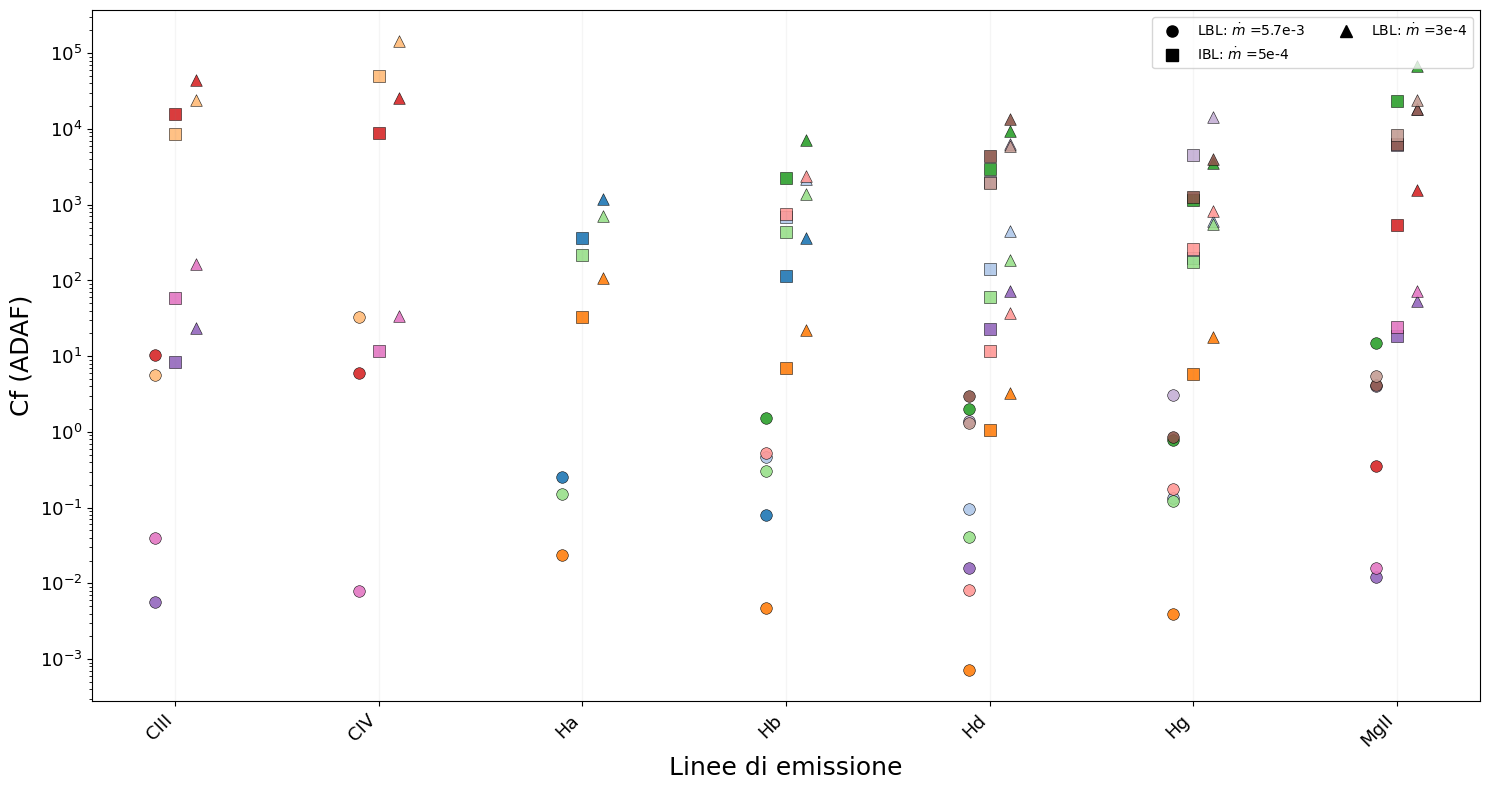

In [27]:
# ==========================================================
# SCATTER: COVERING FACTOR VS LINEA
# colore = blazar
# marker = scenario
# ==========================================================

df_plot_adaf = df_risultati_finali_adaf.copy()

df_plot_adaf = df_plot_adaf[df_plot_adaf["covering_factor"].notna()].copy()
df_plot_adaf = df_plot_adaf[df_plot_adaf["covering_factor"] > 0].copy()

ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_plot_adaf["line_name"].dropna().unique().tolist()
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

ordine_blazar = df_all["label"].drop_duplicates().tolist()
x_map = {linea: i for i, linea in enumerate(linee_uniche)}
df_plot_adaf["x_base"] = df_plot_adaf["line_name"].map(x_map)

offset_values = np.linspace(-0.10, 0.10, len(ordine_scenari_adaf))
offset_scenario = dict(zip(ordine_scenari_adaf, offset_values))

df_plot_adaf["scenario"] = pd.Categorical(
    df_plot_adaf["scenario"],
    categories=ordine_scenari_adaf,
    ordered=True
)

df_plot_adaf["x"] = (
    df_plot_adaf["x_base"] +
    df_plot_adaf["scenario"].map(offset_scenario).astype(float)
)

cmap = plt.get_cmap("tab20")
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(ordine_blazar)}

marker_list = ["o", "s", "^", "D", "v", "P", "X", "*"]
marker_map_scenario = {
    scenario: marker_list[i % len(marker_list)]
    for i, scenario in enumerate(ordine_scenari_adaf)
}

fig, ax = plt.subplots(figsize=(15, 8))

for blazar in ordine_blazar:
    df_bl = df_plot_adaf[df_plot_adaf["label"] == blazar].copy()
    if df_bl.empty:
        continue

    for scenario in ordine_scenari_adaf:
        grp = df_bl[df_bl["scenario"] == scenario].copy()
        if grp.empty:
            continue

        ax.scatter(
            grp["x"],
            grp["covering_factor"],
            color=color_map_blazar[blazar],
            marker=marker_map_scenario[scenario],
            s=70,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.4,
            zorder=2
        )

ax.set_xticks(range(len(linee_uniche)))
ax.set_xticklabels(linee_uniche, rotation=45, ha="right", fontsize=13)
ax.set_yscale("log")
ax.set_xlabel("Linee di emissione", fontsize=18)
ax.set_ylabel("Cf (ADAF)", fontsize=18)
ax.tick_params(axis="y", labelsize=13)

for i in range(len(linee_uniche)):
    ax.axvline(i, color="gray", alpha=0.08, lw=1)

legend_handles = [
    Line2D(
        [0], [0],
        marker=marker_map_scenario[scenario],
        color="black",
        linestyle="None",
        markersize=8,
        label=scenario
    )
    for scenario in ordine_scenari_adaf
]
"""
legend_handles += [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=color_map_blazar[blazar],
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=blazar
    )
    for blazar in ordine_blazar
]
"""
ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fontsize=10,
    ncol=2
)

plt.tight_layout()
plt.show()

## Correlazione con redshift

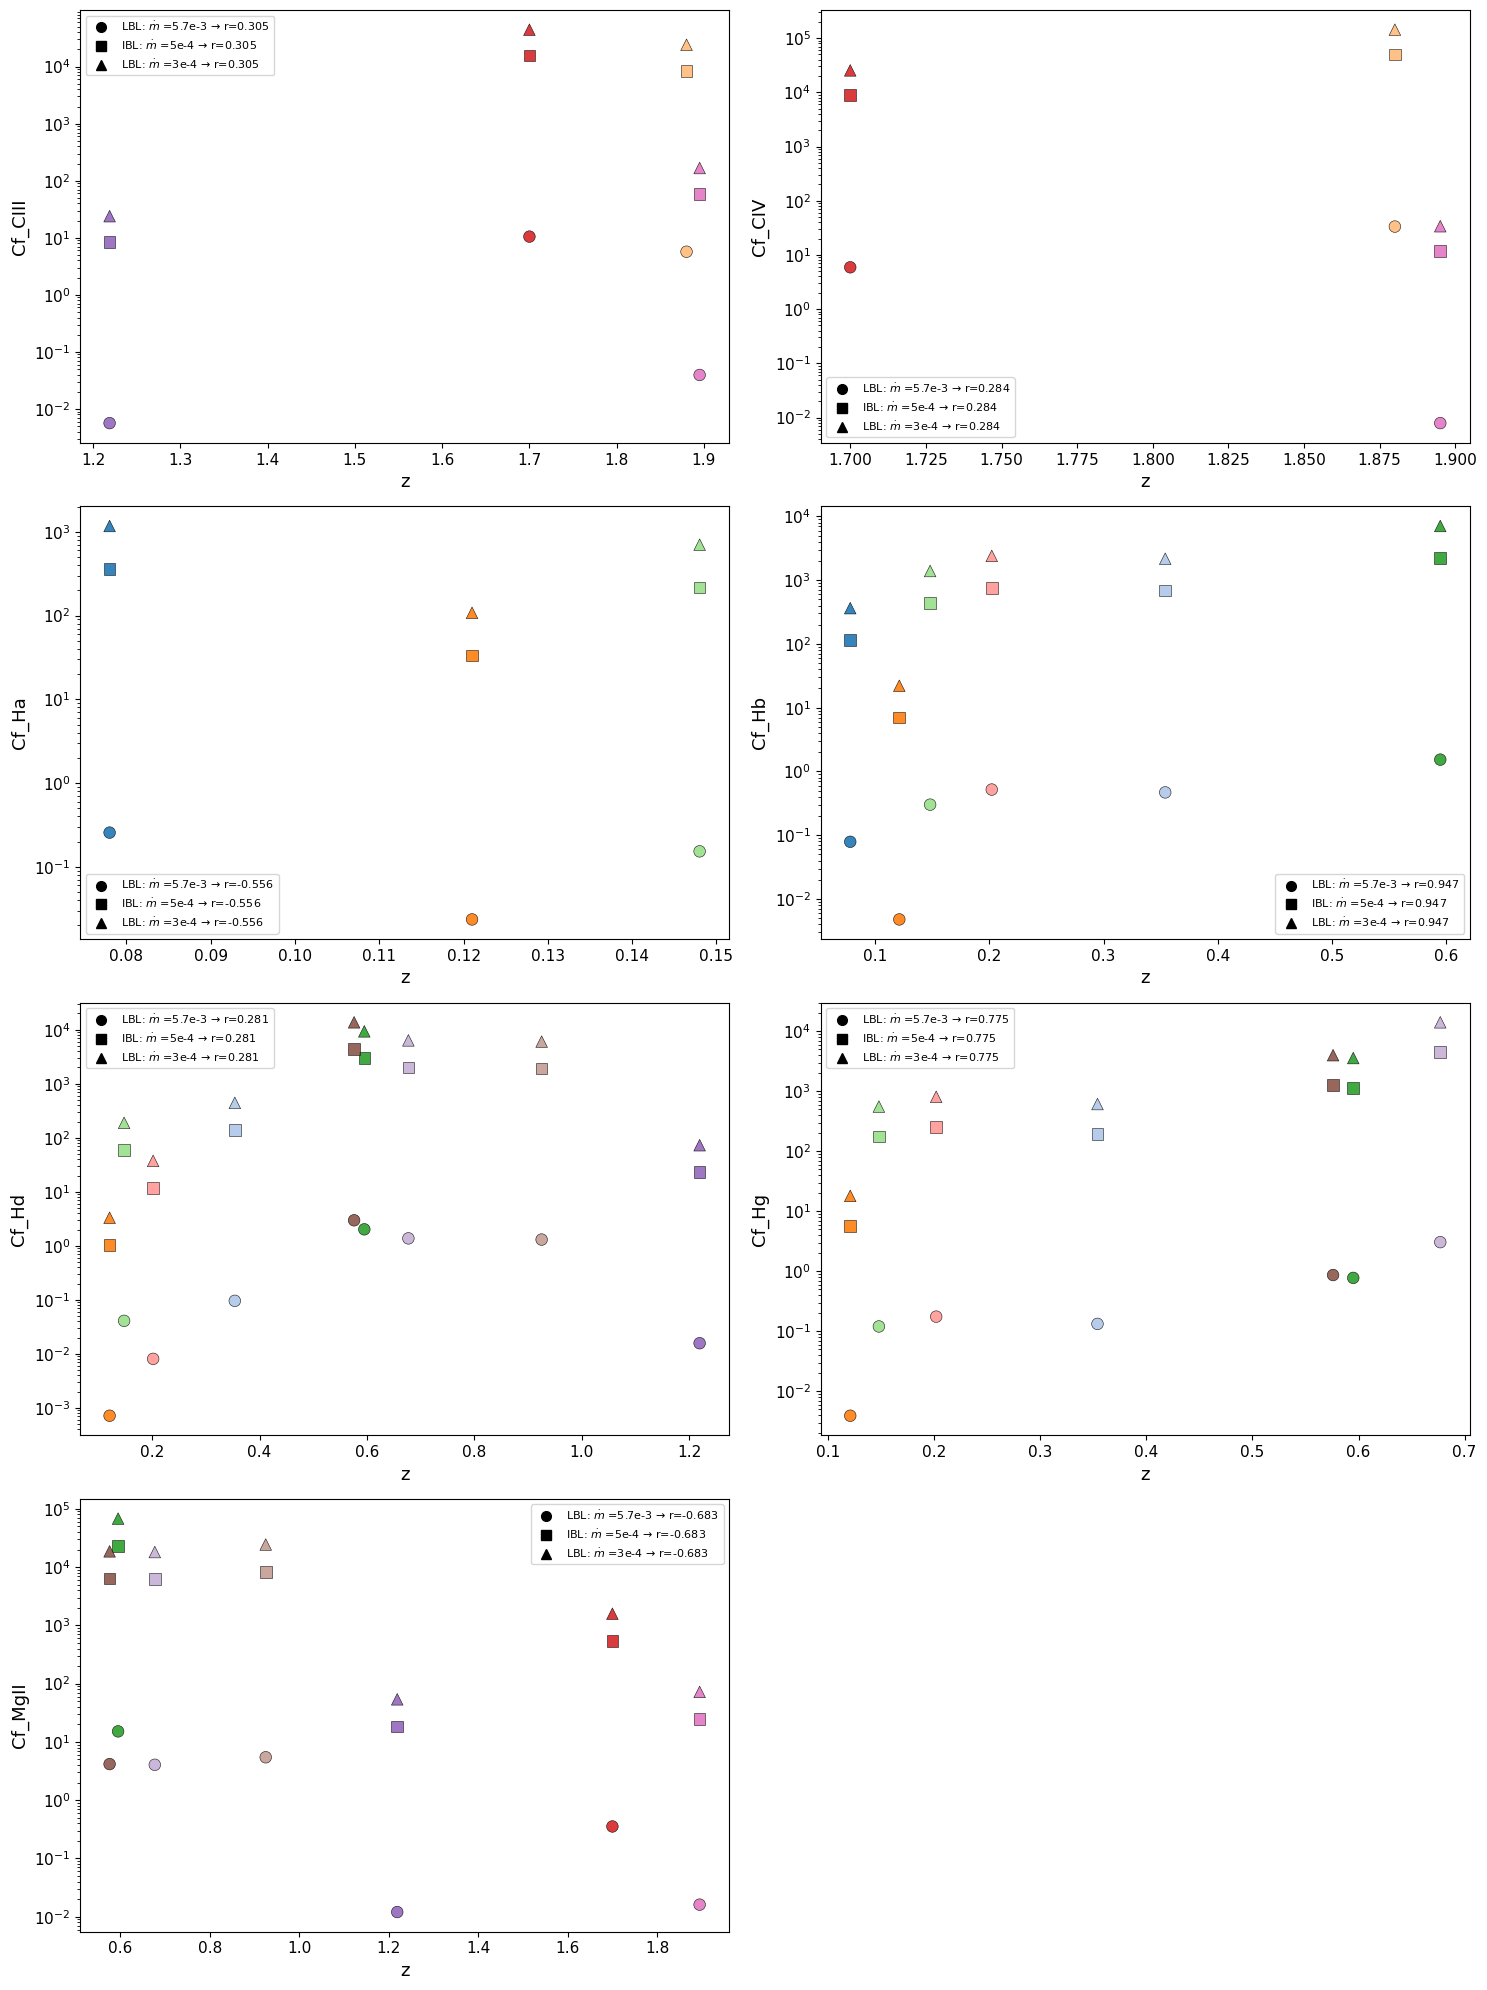

In [28]:
# ==========================================================
# PEARSON: Cf_linea vs redshift per linea
# colore = blazar
# marker = scenario
# legenda = solo scenari + Pearson
# ==========================================================

col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_cf_z = df_risultati_finali_adaf.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "z"}),
    on="label",
    how="left"
)

df_cf_z["z"] = pd.to_numeric(df_cf_z["z"], errors="coerce")
df_cf_z["covering_factor"] = pd.to_numeric(df_cf_z["covering_factor"], errors="coerce")

df_cf_z = df_cf_z[
    (df_cf_z["z"].notna()) &
    (df_cf_z["covering_factor"].notna()) &
    (df_cf_z["covering_factor"] > 0)
].copy()

ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_cf_z["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

blazar_unici = df_cf_z["label"].drop_duplicates().tolist()
cmap = plt.get_cmap("tab20")
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(blazar_unici)}

n_linee = len(linee_uniche)
ncols = 2
nrows = int(np.ceil(n_linee / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, linea in zip(axes, linee_uniche):
    df_linea = df_cf_z[df_cf_z["line_name"] == linea].copy()

    if df_linea.empty:
        ax.axis("off")
        continue

    for scenario in ordine_scenari_adaf:
        df_sc = df_linea[df_linea["scenario"] == scenario]

        if df_sc.empty:
            continue

        ax.scatter(
            df_sc["z"],
            df_sc["covering_factor"],
            c=[color_map_blazar[b] for b in df_sc["label"]],
            marker=marker_map_scenario[scenario],
            s=70,
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9
        )

    legend_handles = []

    for scenario in ordine_scenari_adaf:
        df_sc = df_linea[df_linea["scenario"] == scenario]

        if (
            len(df_sc) >= 2 and
            df_sc["z"].nunique() > 1 and
            df_sc["covering_factor"].nunique() > 1
        ):
            r = df_sc["z"].corr(df_sc["covering_factor"])
            r_txt = f"{r:.3f}"
        else:
            r_txt = "nan"

        legend_handles.append(
            Line2D(
                [0], [0],
                marker=marker_map_scenario[scenario],
                color="black",
                linestyle="None",
                markersize=7,
                label=rf"{scenario} → r={r_txt}"
            )
        )

    ax.set_xlabel("z", fontsize=13)
    ax.set_ylabel(f"Cf_{linea}", fontsize=13)
    ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=11)

    ax.legend(
        handles=legend_handles,
        loc="best",
        fontsize=8,
        frameon=True
    )

for j in range(len(linee_uniche), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Punti totali disponibili: 117


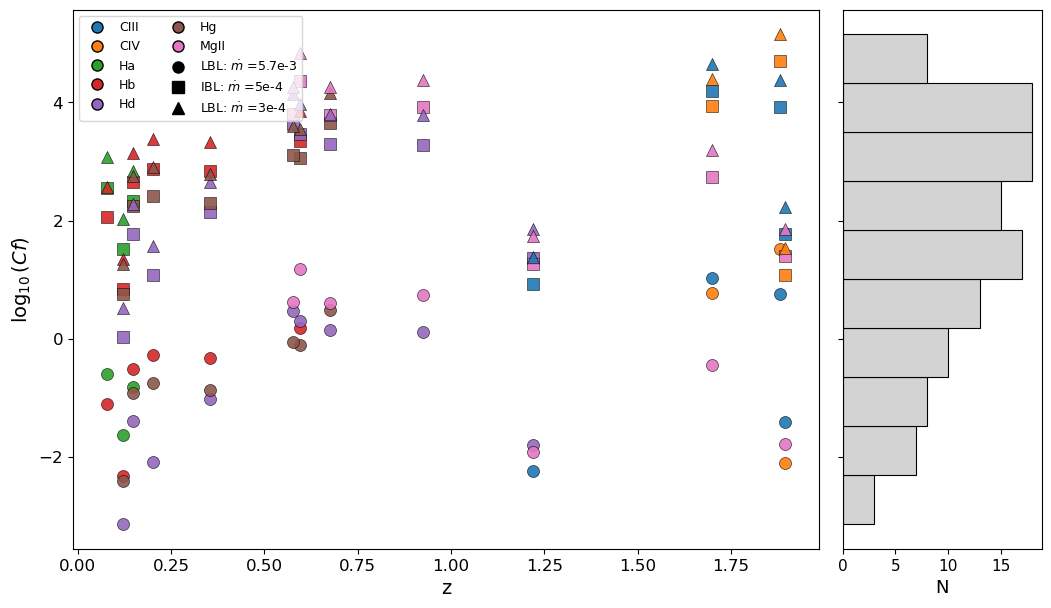

In [29]:
# ==========================================================
# z vs log10(Cf) + istogramma laterale
# colore = linea
# marker = scenario
# ==========================================================

df_kde = df_risultati_finali_adaf.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "z"}),
    on="label",
    how="left"
)

df_kde["covering_factor"] = pd.to_numeric(df_kde["covering_factor"], errors="coerce")
df_kde["z"] = pd.to_numeric(df_kde["z"], errors="coerce")

df_kde = df_kde[
    df_kde["covering_factor"].notna() &
    (df_kde["covering_factor"] > 0) &
    df_kde["z"].notna()
].copy()

df_kde["log_cf"] = np.log10(df_kde["covering_factor"])

print(f"Punti totali disponibili: {len(df_kde)}")

ordine_linee = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_kde["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

palette = sns.color_palette("tab10", len(linee_uniche))
color_map_linea = dict(zip(linee_uniche, palette))

logcf_min = df_kde["log_cf"].min()
logcf_max = df_kde["log_cf"].max()
bins_hist = np.linspace(logcf_min, logcf_max, 11)

fig = plt.figure(figsize=(12.5, 7))
gs = GridSpec(1, 2, width_ratios=[4.5, 1.2], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1], sharey=ax)

for scenario in ordine_scenari_adaf:
    df_s = df_kde[df_kde["scenario"] == scenario]

    for linea in linee_uniche:
        df_sl = df_s[df_s["line_name"] == linea]
        if df_sl.empty:
            continue

        ax.scatter(
            df_sl["z"],
            df_sl["log_cf"],
            color=color_map_linea[linea],
            marker=marker_map_scenario[scenario],
            s=75,
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9
        )

ax.set_xlabel("z", fontsize=14)
ax.set_ylabel(r"$\log_{10}(Cf)$", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

legend_handles = []

for linea in linee_uniche:
    legend_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=color_map_linea[linea],
            markeredgecolor="black",
            markersize=8,
            linestyle="None",
            label=linea
        )
    )

for scenario in ordine_scenari_adaf:
    legend_handles.append(
        Line2D(
            [0], [0],
            marker=marker_map_scenario[scenario],
            color="black",
            linestyle="None",
            markersize=8,
            label=scenario
        )
    )

ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=9,
    frameon=True,
    ncol=2
)

ax_hist.hist(
    df_kde["log_cf"],
    bins=bins_hist,
    orientation="horizontal",
    color="lightgray",
    edgecolor="black",
    linewidth=0.8
)

ax_hist.set_xlabel("N", fontsize=13)
ax_hist.tick_params(axis="x", labelsize=11)
ax_hist.tick_params(axis="y", labelleft=False)

plt.subplots_adjust(wspace=0.05)
plt.show()

Punti totali disponibili: 117


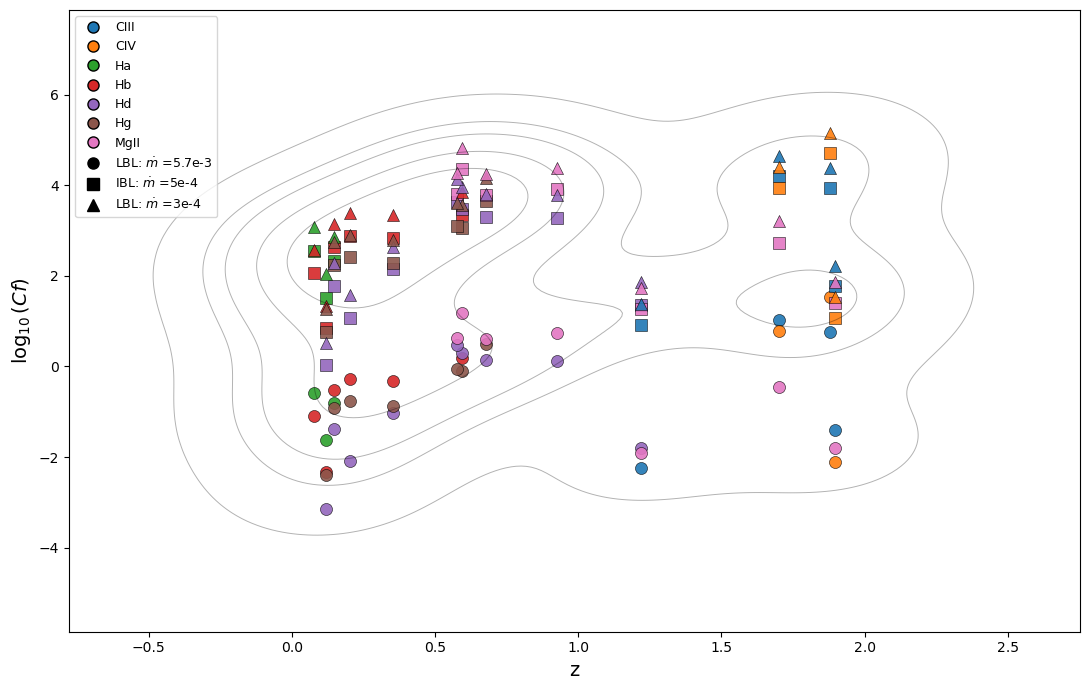

In [30]:

# =========================
# PREPARAZIONE DATI
# =========================
col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_kde = df_risultati_finali_adaf.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_kde["covering_factor"] = pd.to_numeric(df_kde["covering_factor"], errors="coerce")
df_kde["redshift"] = pd.to_numeric(df_kde["redshift"], errors="coerce")

df_kde = df_kde[
    df_kde["covering_factor"].notna() &
    (df_kde["covering_factor"] > 0) &
    df_kde["redshift"].notna()
].copy()

df_kde["log_cf"] = np.log10(df_kde["covering_factor"])

print(f"Punti totali disponibili: {len(df_kde)}")

# =========================
# ORDINE LINEE E SCENARI
# =========================
ordine_linee = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_kde["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in ordine_linee]

ordine_scenari = [s["scenario"] for s in SCENARI_ADAF]

# =========================
# COLORI E MARKER
# =========================
palette = sns.color_palette("tab10", len(linee_uniche))
color_map_linea = dict(zip(linee_uniche, palette))

marker_list = ["o", "s", "^", "D", "v", "P", "X", "*"]
marker_map = {
    scenario: marker_list[i % len(marker_list)]
    for i, scenario in enumerate(ordine_scenari)
}

# =========================
# GRAFICO
# =========================
fig, ax = plt.subplots(figsize=(11, 7))

# KDE nel piano corretto (z, log CF)
if len(df_kde) >= 3:
    sns.kdeplot(
        data=df_kde,
        x="redshift",
        y="log_cf",
        levels=6,
        color="black",
        linewidths=0.7,
        alpha=0.30,
        ax=ax
    )

# scatter
for scenario in ordine_scenari:
    df_s = df_kde[df_kde["scenario"] == scenario]

    for linea in linee_uniche:
        df_sl = df_s[df_s["line_name"] == linea]
        if df_sl.empty:
            continue

        ax.scatter(
            df_sl["redshift"],
            df_sl["log_cf"],
            color=color_map_linea[linea],
            marker=marker_map[scenario],
            s=75,
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9
        )

# assi
ax.set_xlabel("z", fontsize=14)
ax.set_ylabel(r"$\log_{10}(Cf)$", fontsize=14)

# =========================
# LEGENDA
# =========================
legend_handles = []

# linee = colori
for linea in linee_uniche:
    legend_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=color_map_linea[linea],
            markeredgecolor="black",
            markersize=8,
            linestyle="None",
            label=linea
        )
    )

# scenari = marker
for scenario in ordine_scenari:
    legend_handles.append(
        Line2D(
            [0], [0],
            marker=marker_map[scenario],
            color="black",
            linestyle="None",
            markersize=8,
            label=scenario
        )
    )

ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

## Correlazione con L_blr

In [36]:
# =========================
# STIMA DI L_BLR_i PER SINGOLA LINEA
# =========================

BLR_WEIGHTS_VANDENBERK = {
    "CIV": 25.291,
    "CIII": 15.943,
    "MgII": 14.725,
    "Hd": 1.066,
    "Hg": 2.616,
    "Hb": 8.649,
    "Ha": 30.832
}

BLR_TOTAL_VANDENBERK = 264.197

# prendo L_line dalle righe ADAF, ma tanto è osservativa quindi è uguale
df_lblr_linee = df_risultati_finali_adaf[["label", "line_name", "L_line"]].copy()
df_lblr_linee = df_lblr_linee.drop_duplicates()

df_lblr_linee["w_i"] = df_lblr_linee["line_name"].map(BLR_WEIGHTS_VANDENBERK)
df_lblr_linee = df_lblr_linee[df_lblr_linee["w_i"].notna()].copy()

df_lblr_linee["L_BLR_i"] = (
    df_lblr_linee["L_line"] * BLR_TOTAL_VANDENBERK / df_lblr_linee["w_i"]
)

print("Tabella L_BLR_i per singola linea:")
display(df_lblr_linee.head())

Tabella L_BLR_i per singola linea:


,label,line_name,L_line,w_i,L_BLR_i
0,J1745.6,Ha,3.631777e+42,30.832,3.112042e+43
1,J1745.6,Hb,1.103068e+42,8.649,3.369490e+43
2,J0021.6-6835,Hb,6.569277e+42,8.649,2.006687e+44
3,J0021.6-6835,Hg,1.867612e+42,2.616,1.886152e+44
4,J0021.6-6835,Hd,1.343418e+42,1.066,3.329522e+44


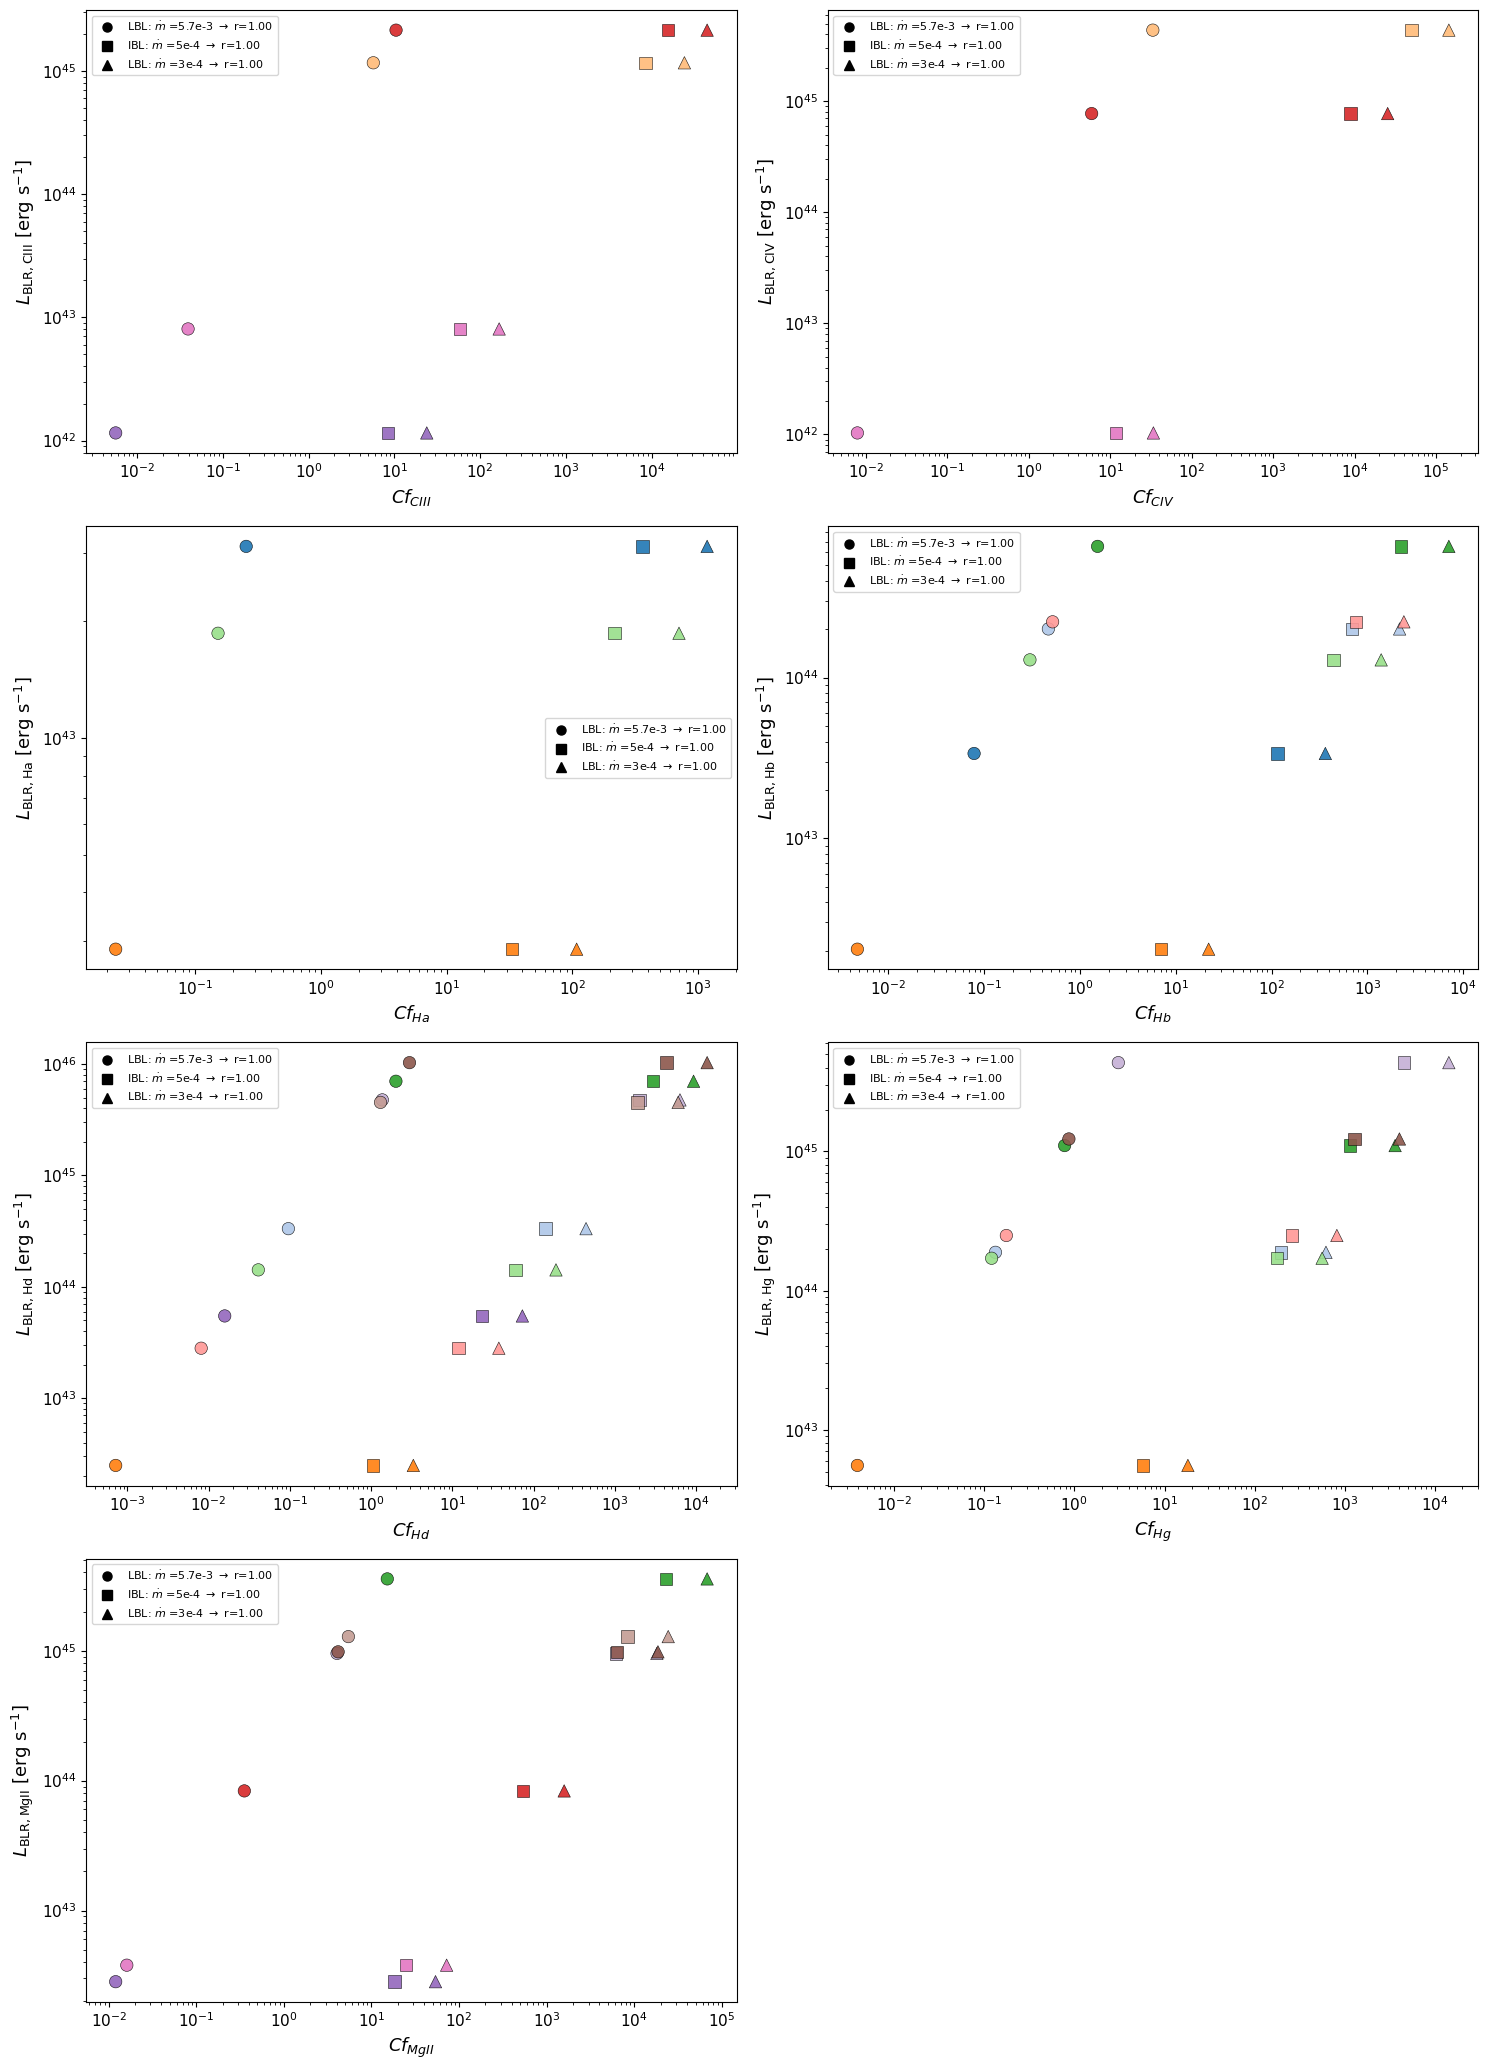

In [38]:
# 1. Covering factor ADAF validi
df_cf_line_adaf = df_risultati_finali_adaf.copy()
df_cf_line_adaf["covering_factor"] = pd.to_numeric(
    df_cf_line_adaf["covering_factor"],
    errors="coerce"
)

df_cf_line_adaf = df_cf_line_adaf[
    df_cf_line_adaf["covering_factor"].notna() &
    (df_cf_line_adaf["covering_factor"] > 0)
].copy()

# 2. L_BLR_i validi
df_lblr_line = df_lblr_linee.copy()
df_lblr_line["L_BLR_i"] = pd.to_numeric(df_lblr_line["L_BLR_i"], errors="coerce")

df_lblr_line = df_lblr_line[
    df_lblr_line["L_BLR_i"].notna() &
    (df_lblr_line["L_BLR_i"] > 0)
].copy()

# 3. Merge su blazar + linea
df_line_adaf = df_cf_line_adaf.merge(
    df_lblr_line[["label", "line_name", "L_BLR_i"]],
    on=["label", "line_name"],
    how="inner"
)

# 4. Ordine linee
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_line_adaf["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

# 5. Ordine scenari ADAF
ordine_scenari_adaf = [s["scenario"] for s in SCENARI_ADAF]

# marker per i 3 scenari
marker_list = ["o", "s", "^", "D", "v", "P", "X"]
marker_map_adaf = {
    scenario: marker_list[i % len(marker_list)]
    for i, scenario in enumerate(ordine_scenari_adaf)
}

# etichette corte per la legenda
scenario_short_label_map_adaf = {
    "LBL_m1e9_mdot5.7e-3_beta0.5": r"LBL $\rightarrow$ r={rval}",
    "IBL_m1e9_mdot5e-4_beta0.5":   r"IBL $\rightarrow$ r={rval}",
    "HBL_m1e9_mdot3e-4_beta0.5":   r"HBL $\rightarrow$ r={rval}",
}

# colori = blazar
blazar_unici = df_line_adaf["label"].drop_duplicates().tolist()
cmap = plt.get_cmap("tab20")
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(blazar_unici)}

# 6. Layout pannelli
n_linee = len(linee_uniche)
ncols = 2
nrows = int(np.ceil(n_linee / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5.2 * nrows))
axes = np.array(axes).reshape(-1)

for ax, linea in zip(axes, linee_uniche):
    df_l = df_line_adaf[df_line_adaf["line_name"] == linea].copy()

    if df_l.empty:
        ax.axis("off")
        continue

    # scatter: marker = scenario, colore = blazar
    for scenario in ordine_scenari_adaf:
        df_s = df_l[df_l["scenario"] == scenario].copy()

        if df_s.empty:
            continue

        ax.scatter(
            df_s["covering_factor"],
            df_s["L_BLR_i"],
            s=80,
            c=[color_map_blazar[b] for b in df_s["label"]],
            marker=marker_map_adaf[scenario],
            edgecolors="black",
            linewidths=0.4,
            alpha=0.9
        )

    # legenda scenari + Pearson
    legend_handles = []

    for scenario in ordine_scenari_adaf:
        df_s = df_l[df_l["scenario"] == scenario].copy()

        if (
            len(df_s) >= 2 and
            df_s["covering_factor"].nunique() > 1 and
            df_s["L_BLR_i"].nunique() > 1
        ):
            pearson = df_s["covering_factor"].corr(df_s["L_BLR_i"], method="pearson")
            pearson_txt = f"{pearson:.2f}"
        else:
            pearson_txt = "nan"

        label_base = scenario_short_label_map_adaf.get(
            scenario,
            scenario + r" $\rightarrow$ r={rval}"
        )

        legend_handles.append(
            Line2D(
                [0], [0],
                marker=marker_map_adaf[scenario],
                color="black",
                linestyle="None",
                markersize=6.5,
                label=label_base.format(rval=pearson_txt)
            )
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$L_{\rm BLR," + linea + r"}$ [erg s$^{-1}$]", fontsize=13)
    ax.set_xlabel(r"$Cf_{" + linea + r"}$", fontsize=13)
    ax.tick_params(axis="both", labelsize=11)

    ax.legend(
        handles=legend_handles,
        loc="best",
        fontsize=8,
        frameon=True,
        ncol=1
    )

# spengo eventuali pannelli vuoti
for j in range(len(linee_uniche), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()